##  Forest Fires Data Analysis and Prediction



### Step 1: Load the Dataset

*   Install and import the ucimlrepo library.
*   Load the Forest Fires dataset:
 *   Predictors: Features from forest_fires.data.features.
 *   Target: forest_fires.data.targets.

In [ ]:
# Run pip install if necessary to access the UCI ML Repository (uncomment the next line)
# ! pip install ucimlrepo

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving forest+fires.zip to forest+fires.zip


In [ ]:
!pip install ucimlrepo

In [ ]:
# Data
from ucimlrepo import fetch_ucirepo


forest_fires = fetch_ucirepo(id=162)
X = forest_fires.data.features
y = forest_fires.data.targets


# Display dataset structure
print(X.info())
print(X.describe())
print(y.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
dtypes: float64(7), int64(3), object(2)
memory usage: 48.6+ KB
None
                X           Y        FFMC         DMC          DC         ISI  \
count  517.000000  517.000000  517.000000  517.000000  517.000000  517.000000   
mean     4.669246    4.299807   90.644681  110.872340  547.940039    9.021663   
std      2.313778    1.229900    5.520111   64.046482  248.066192 

### Step 2: EDA

* Examine the dataset structure and summary statistics.
* Analyze correlations between predictors and the target variable.
* Plot scatterplots for key predictors vs. the target.
* Generate a residual plot to check for randomness in residuals.

Dataset shape: (517, 13)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
 12  target  517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB
None

Summary statistics:
                X           Y        FFMC         DMC          DC         ISI  \
count  517.000000  517.000000  517.000000  517.000000  517.000000  517.000000   
mean     4.669246    4.299807   90.644681 

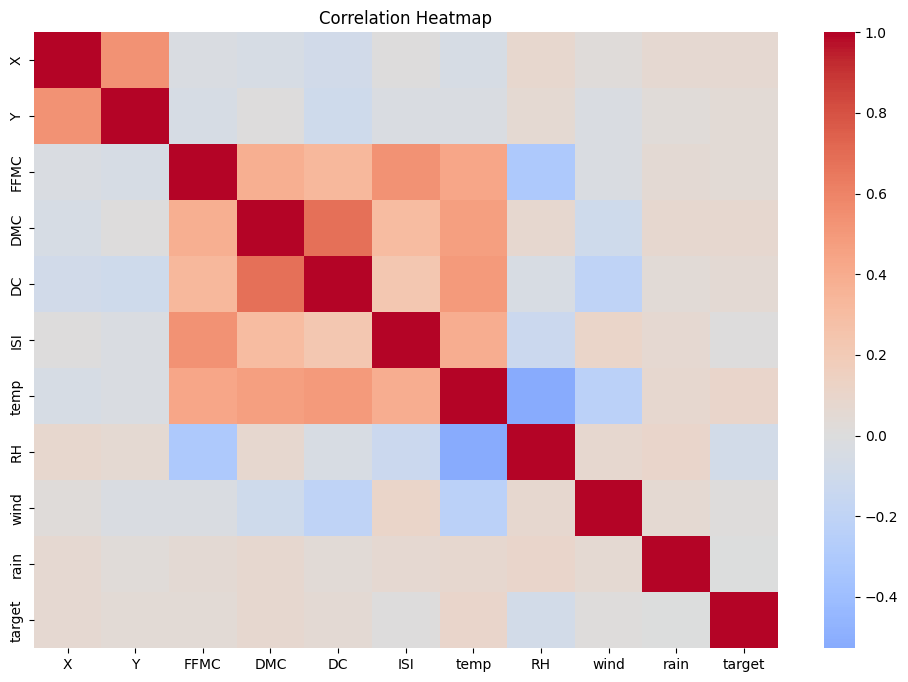

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = X.copy()
df["target"] = y.iloc[:, 0]

print("Dataset shape:", df.shape)
print("\nDataset information:")
print(df.info())

print("\nSummary statistics:")
print(df.describe())

print("\nCorrelations with target:")
print(df.corr(numeric_only=True)["target"].sort_values(ascending=False))

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

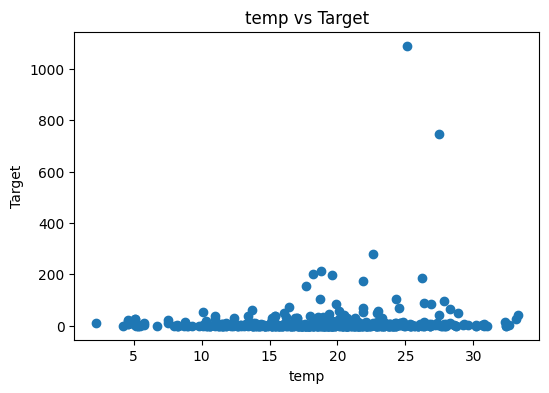

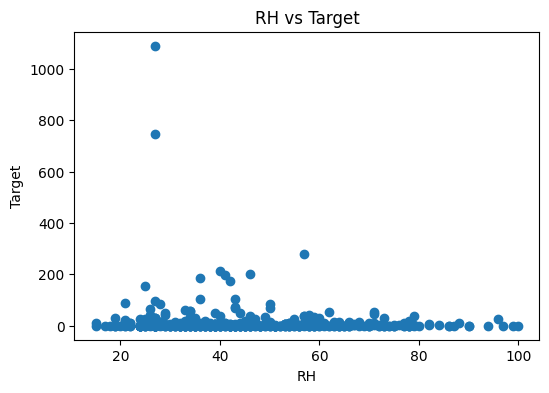

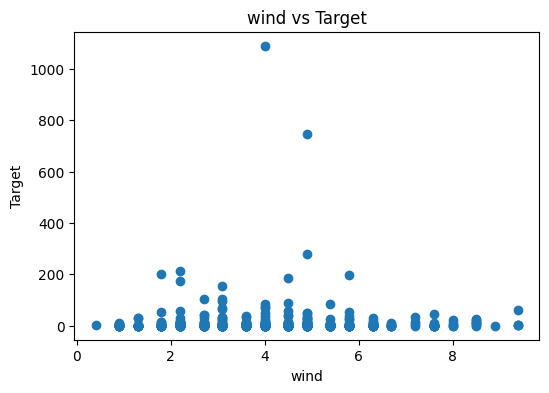

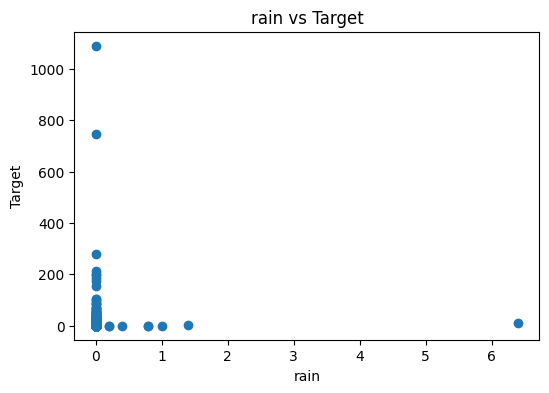

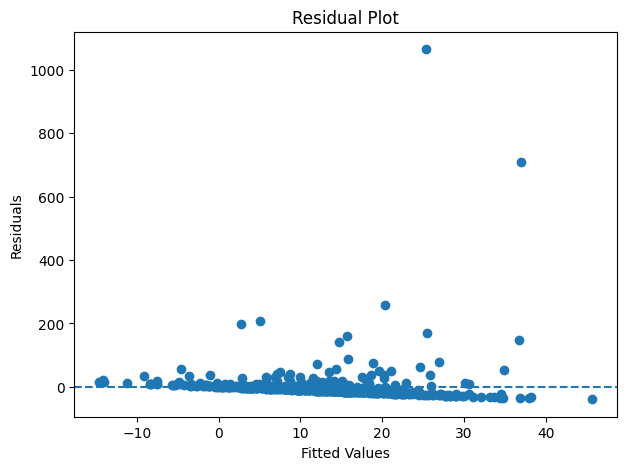

In [ ]:
from sklearn.linear_model import LinearRegression

key_predictors = ["temp", "RH", "wind", "rain"]

for col in key_predictors:
    plt.figure(figsize=(6, 4))
    plt.scatter(X[col], y.iloc[:, 0])
    plt.xlabel(col)
    plt.ylabel("Target")
    plt.title(f"{col} vs Target")
    plt.show()

numeric_X = X.select_dtypes(include="number")
model = LinearRegression()
model.fit(numeric_X, y.iloc[:, 0])

predictions = model.predict(numeric_X)
residuals = y.iloc[:, 0] - predictions

plt.figure(figsize=(7, 5))
plt.scatter(predictions, residuals)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

### Step 3: Fit the regression models

* Fit a baseline multiple linear regression model with key predictors.
* Include nonlinear terms (e.g., quadratic transformations for significant predictors).
* Add interaction terms (e.g., between predictors with strong correlations).
* Incorporate indicator variables if categorical variables are present.
* Apply transformations (e.g., logarithmic transformations for skewed predictors).

In [ ]:
import statsmodels.formula.api as smf

df = X.copy()
df["target"] = y.iloc[:, 0]

baseline_model = smf.ols(
    "target ~ temp + RH + wind + rain",
    data=df
).fit()

print(baseline_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.512
Date:                Sat, 26 Sep 2026   Prob (F-statistic):              0.197
Time:                        05:30:27   Log-Likelihood:                -2877.4
No. Observations:                 517   AIC:                             5765.
Df Residuals:                     512   BIC:                             5786.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -6.4385     20.159     -0.319      0.7

In [ ]:
import numpy as np

df["temp_squared"] = df["temp"] ** 2
df["temp_RH"] = df["temp"] * df["RH"]

df["high_temp"] = (df["temp"] > df["temp"].median()).astype(int)

df["log_wind"] = np.log1p(df["wind"])

extended_model = smf.ols(
    "target ~ temp + RH + wind + rain + temp_squared + temp_RH + high_temp + log_wind",
    data=df
).fit()

print(extended_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.9571
Date:                Sat, 26 Sep 2026   Prob (F-statistic):              0.469
Time:                        05:30:28   Log-Likelihood:                -2876.6
No. Observations:                 517   AIC:                             5771.
Df Residuals:                     508   BIC:                             5809.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept      -26.4193     49.527     -0.533   

### Step 4: Evaluate model diagnostics

* Compare models using metrics like 2R^2, adjusted RR^2, AIC, and BIC.
* Plot residuals and create Q-Q plots to assess normality.
* Identify influential observations using Cook's Distance.

In [ ]:
model_comparison = pd.DataFrame({
    "Model": ["Baseline", "Extended"],
    "R-squared": [baseline_model.rsquared, extended_model.rsquared],
    "Adjusted R-squared": [baseline_model.rsquared_adj, extended_model.rsquared_adj],
    "AIC": [baseline_model.aic, extended_model.aic],
    "BIC": [baseline_model.bic, extended_model.bic]
})

print(model_comparison)

      Model  R-squared  Adjusted R-squared          AIC          BIC
0  Baseline   0.011676            0.003955  5764.818979  5786.059193
1  Extended   0.014849           -0.000665  5771.156381  5809.388767


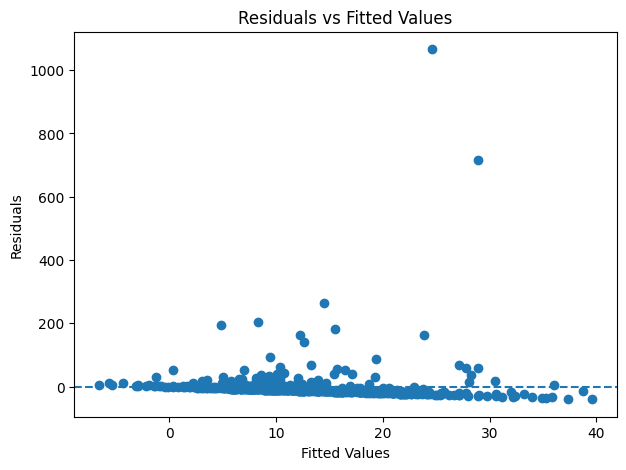

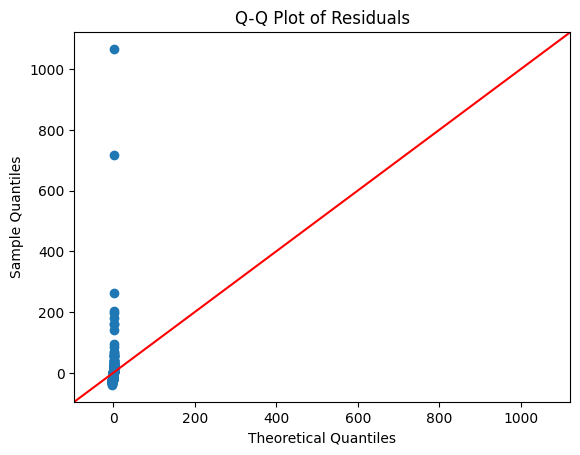

In [ ]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

residuals = extended_model.resid
fitted = extended_model.fittedvalues

# Residual plot
plt.figure(figsize=(7, 5))
plt.scatter(fitted, residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

# Q-Q plot
sm.qqplot(residuals, line="45")
plt.title("Q-Q Plot of Residuals")
plt.show()

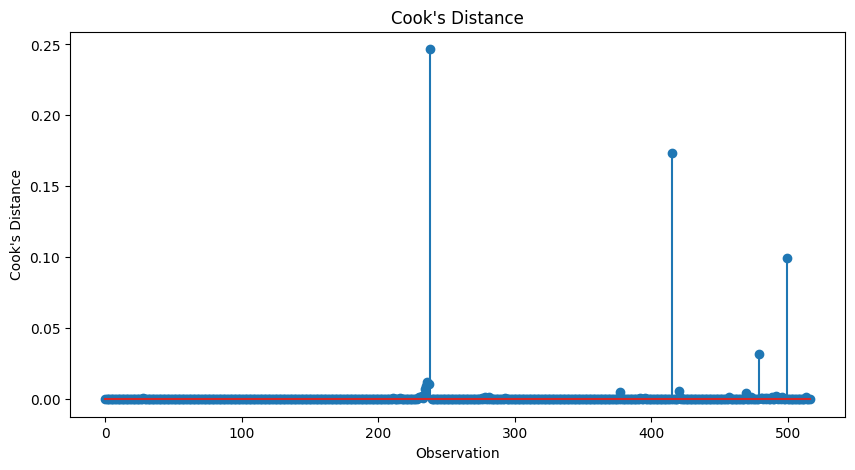

Potentially influential observations:
[235 236 237 238 415 479 499]


In [ ]:
influence = extended_model.get_influence()
cooks_distance = influence.cooks_distance[0]

plt.figure(figsize=(10, 5))
plt.stem(range(len(cooks_distance)), cooks_distance)
plt.xlabel("Observation")
plt.ylabel("Cook's Distance")
plt.title("Cook's Distance")
plt.show()

# Identify potentially influential observations
influential = np.where(cooks_distance > 4 / len(df))[0]

print("Potentially influential observations:")
print(influential)

### Step 5: Apply regularization

* Use Ridge (L2) and Lasso (L1) regression from sklearn to handle multicollinearity.
* Extract coefficients and calculate Mean Squared Error (MSE).
* Compare the performance of Ridge and Lasso models.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error

# Use numeric predictors
X_numeric = X.select_dtypes(include="number")
y_numeric = y.iloc[:, 0]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X_numeric, y_numeric, test_size=0.2, random_state=42
)

# Standardize predictors
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Ridge regression (L2)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
ridge_pred = ridge.predict(X_test_scaled)
ridge_mse = mean_squared_error(y_test, ridge_pred)

# Lasso regression (L1)
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)
lasso_pred = lasso.predict(X_test_scaled)
lasso_mse = mean_squared_error(y_test, lasso_pred)

print("Ridge coefficients:")
print(ridge.coef_)

print("\nLasso coefficients:")
print(lasso.coef_)

print("\nRidge MSE:", ridge_mse)
print("Lasso MSE:", lasso_mse)

Ridge coefficients:
[ 4.88973298  0.08672899 -0.58183444  7.22600669 -2.55027652 -1.1530876
  2.33858532 -3.14720921  1.5004819  -0.80905242]

Lasso coefficients:
[ 4.81830708  0.05272271 -0.4473181   6.90320173 -2.26870923 -0.99632159
  2.1402166  -3.04969644  1.35986062 -0.70066126]

Ridge MSE: 11759.696470196677
Lasso MSE: 11762.490954649216


In [ ]:

comparison = pd.DataFrame({
    "Model": ["Ridge", "Lasso"],
    "MSE": [ridge_mse, lasso_mse]
})

print(comparison)

   Model           MSE
0  Ridge  11759.696470
1  Lasso  11762.490955


### Step 6: Prepare the data for binary classification

* Create a binary target variable based on a threshold in y (e.g., median or other percentile).
* Select relevant predictors and scale them using StandardScaler.

In [ ]:
import numpy as np

# Create binary target using the median of area
threshold = y.iloc[:, 0].median()

y_binary = (y.iloc[:, 0] > threshold).astype(int)

print("Threshold:", threshold)
print("\nBinary target counts:")
print(y_binary.value_counts())

Threshold: 0.52

Binary target counts:
area
0    259
1    258
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Select numeric predictors
X_selected = X.select_dtypes(include="number")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y_binary,
    test_size=0.2,
    random_state=42
)

# Scale predictors
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training shape:", X_train_scaled.shape)
print("Testing shape:", X_test_scaled.shape)

Training shape: (413, 10)
Testing shape: (104, 10)


### Step 7: Train and evaluate a logistic regression model

Train a logistic regression model using the scaled predictors.

* Display coefficients and the intercept.
* Predict probabilities and binary outcomes.
* Evaluate performance using accuracy, confusion matrix, precision, recall, and F1-score.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Create binary target
y_binary = (y.iloc[:, 0] > 0).astype(int)

# Use numeric predictors
X_numeric = X.select_dtypes(include="number")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_numeric, y_binary, test_size=0.2, random_state=42
)

# Scale predictors
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Classes:", y_binary.unique())
print("Class counts:")
print(y_binary.value_counts())

Classes: [0 1]
Class counts:
area
1    270
0    247
Name: count, dtype: int64


In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

print("Coefficients:")
print(log_model.coef_)

print("\nIntercept:")
print(log_model.intercept_)

# Predict probabilities
y_prob = log_model.predict_proba(X_test_scaled)[:, 1]

# Predict binary outcomes
y_pred = log_model.predict(X_test_scaled)

print("\nFirst 10 predicted probabilities:")
print(y_prob[:10])

print("\nFirst 10 binary predictions:")
print(y_pred[:10])

Coefficients:
[[ 0.1100593   0.10020275  0.22062    -0.02668508  0.18192194 -0.12611984
   0.07329188  0.00429948  0.17241121  0.02578255]]

Intercept:
[0.10002155]

First 10 predicted probabilities:
[0.47692788 0.63329688 0.59698809 0.553605   0.50807156 0.44140642
 0.48547066 0.48482757 0.52422813 0.45239331]

First 10 binary predictions:
[0 1 1 1 1 0 0 0 1 0]


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nPrecision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

Accuracy: 0.5480769230769231

Confusion Matrix:
[[19 32]
 [15 38]]

Precision: 0.5428571428571428
Recall: 0.7169811320754716
F1-Score: 0.6178861788617886


### Step 8: Check assumptions

* Use Variance Inflation Factor (VIF) to assess multicollinearity among predictors.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Select numeric predictors
X_vif = X.select_dtypes(include="number").copy()

# Calculate VIF
vif = pd.DataFrame()
vif["Predictor"] = X_vif.columns
vif["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print(vif)

  Predictor       VIF
0         X  1.433429
1         Y  1.445610
2      FFMC  1.698060
3       DMC  2.361567
4        DC  2.125930
5       ISI  1.579370
6      temp  2.666717
7        RH  1.913799
8      wind  1.142779
9      rain  1.047796


### Step 9: Summative Findings

* Compare regression models and classification results.
* Highlight trade-offs between model simplicity, performance, and interpretability.
* Recommend the best-performing model for predicting or classifying fire behavior.

## Summary of Findings

The Forest Fires dataset was analyzed using linear regression, extended regression, Ridge, Lasso, and logistic regression. The extended regression model included nonlinear, interaction, indicator, and log-transformed terms to capture more complex relationships.

Ridge and Lasso produced similar results, with Ridge achieving a slightly lower test MSE of **11,759.70** compared with **11,762.49** for Lasso. Logistic regression achieved **54.81% accuracy**, **54.29% precision**, **71.70% recall**, and an **F1-score of 61.79%**.

VIF analysis showed that all predictors had VIF values below 5, indicating no serious multicollinearity. Residual plots, Q-Q plots, and Cook's Distance were used to assess regression assumptions and identify potentially influential observations.

Overall, Ridge provided slightly better predictive performance than Lasso for continuous burned-area prediction, while logistic regression showed stronger recall than overall accuracy for classifying above-median burned area. The results demonstrate the trade-off between model simplicity, interpretability, and predictive performance.


## Conclusion

The analysis compared regression and classification approaches for the Forest Fires dataset. Ridge regression achieved a slightly lower test MSE than Lasso, while logistic regression achieved 54.81% accuracy and 71.70% recall. VIF analysis showed no serious multicollinearity among the predictors. The results demonstrate the trade-off between model complexity, interpretability, and predictive performance.